# Facial Image Restoration with a Deep Variational Autoencoder (VAE)

This project implements a Deep Variational Autoencoder (VAE) to perform image restoration, specifically focusing on in-painting, or filling in missing parts of an image.

### The Goal
The primary objective is to train a generative model that can take a corrupted image (with a black square obscuring a part of it) and reconstruct the original, complete image.

### The Dataset
**CelebFaces Attributes (CelebA) Dataset**\
A popular component of computer vision and deep learning revolves around identifying faces for various applications from logging into your phone with your face or searching through surveillance images for a particular suspect. This dataset is great for training and testing models for face detection, particularly for recognising facial attributes such as finding people with brown hair, are smiling, or wearing glasses. Images cover large pose variations, background clutter, diverse people, supported by a large quantity of images and rich annotations. This data was originally collected by researchers at MMLAB, The Chinese University of Hong Kong (specific reference in Acknowledgment section).

### The Model: Variational Autoencoder (VAE)
A VAE is a type of generative model that learns to compress data into a structured, low-dimensional representation (the **latent space**) and then reconstruct it back. It consists of two main parts:
1.  **Encoder:** Compresses the input image into a probability distribution in the latent space.
2.  **Decoder:** Samples a point from this latent space and reconstructs the full image.

By training on pairs of corrupted and original images, the VAE learns a meaningful representation that allows it to intelligently "imagine" the content of the missing sections.

## Data Preprocessing and Preparation

Before we can train our model, we first need to prepare our dataset. This involves several key steps:
1.  **Creating Corrupted Images:** We generate a "corrupted" version for each image by masking a random portion with a black square.
2.  **Resizing and Normalization:** All images are resized to a uniform dimension and their pixel values are scaled to a [0, 1] range for stable and efficient training.
3.  **Train/Validation Split:** The dataset is split into a training set (to train the model) and a validation set (to evaluate its performance on unseen data).
4.  **Reproducibility:** A random seed is set to ensure that all random processes (like the mask placement and data shuffling) are the same every time the script is run, making our experiment reproducible.

### Core Preprocessing Functions

These functions form the heart of our data preparation pipeline.

#### `create_variable_missing_part(image)`
This function takes an image and creates its "corrupted" counterpart.
* It calculates a random mask area, ranging from **5% to 30%** of the total image area. This variability makes the model more robust, as it learns to handle missing sections of different sizes.
* A black square of this calculated area is then placed at a random location on the image.

#### `process_and_save_image(...)`
This function orchestrates the full preprocessing pipeline for a single image:
1.  **Resize:** Resizes the input image to the defined `IMAGE_SIZE`.
2.  **Augment:** With a 50% chance, it performs a horizontal flip on the image. It's critical that the same augmentation is applied to both the original and corrupted versions.
3.  **Normalize:** It converts the pixel values from the standard `0-255` range to a `0-1` floating-point range by dividing by 255. This is a standard practice that helps stabilize and speed up the training of deep neural networks.
4.  **Corrupt & Save:** It calls `create_variable_missing_part` on the processed image and saves both the final original and corrupted versions to disk.

#### `split_and_preprocess_dataset(...)`
1.  **Directory Setup:** It first cleans up any old data and creates a structured output directory with `train` and `validation` subfolders, each containing `original` and `corrupted` directories.
2.  **File Shuffling & Splitting:** It lists all image files, sorts them for consistency, and then shuffles them deterministically using our `SEED`. The dataset is then split into a **70% training** set and a **30% validation** set.
3.  **Processing Loop:** It iterates through the training and validation file lists, calling `process_and_save_image` for each one to execute the preprocessing and save the results in the appropriate folders.

Seed set to 42 for reproducibility. 
Splitting dataset: 21000 training images, 9000 validation images.

Processing training set...


100%|██████████| 21000/21000 [03:21<00:00, 104.27it/s]



Processing validation set...


100%|██████████| 9000/9000 [01:22<00:00, 109.29it/s]



Dataset preprocessing complete! ✨


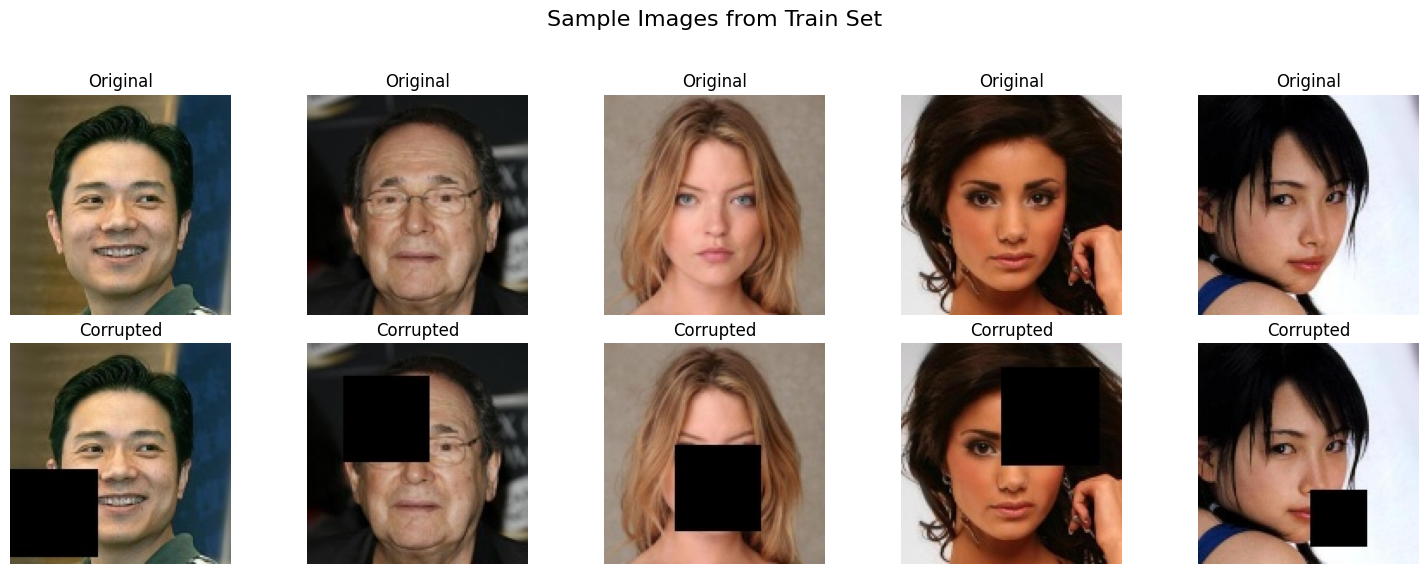

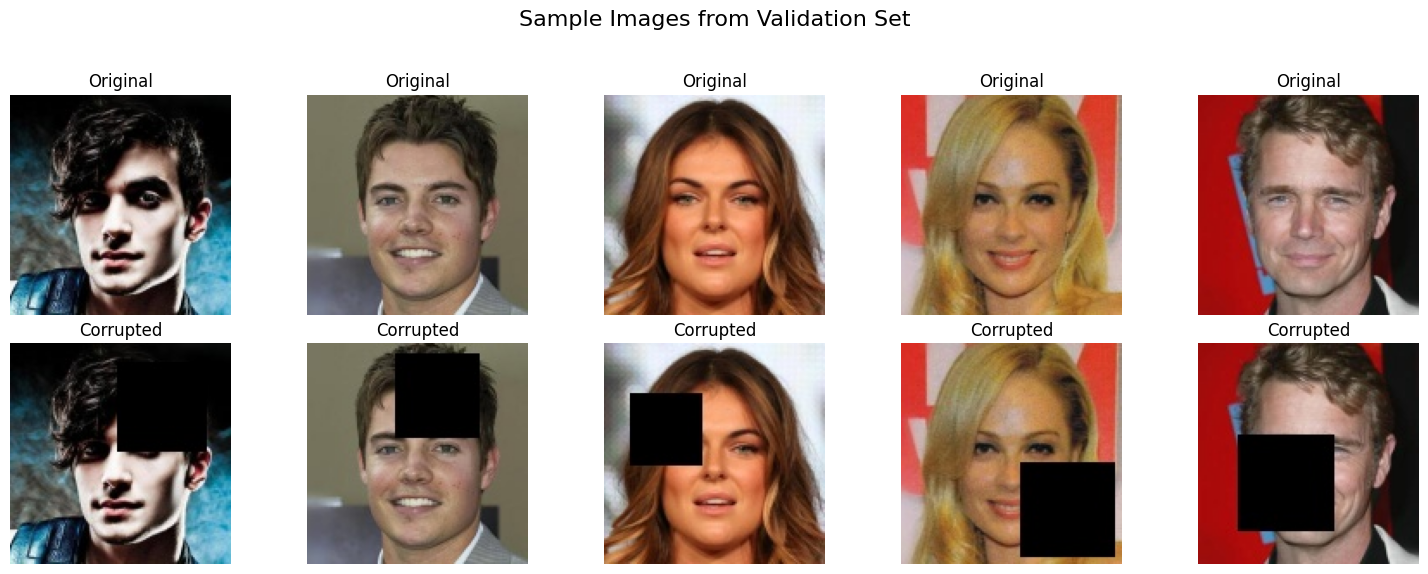

In [2]:
import os
import cv2
import numpy as np
import random
import shutil
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- Configuration Options ---
IMAGE_SIZE = (128, 128)  # Resize images to 128x128 pixels
APPLY_AUGMENTATION = False # Set to True to apply data augmentation
SEED = 42                # A fixed seed for reproducibility

def set_seed(seed):
    """Sets the seed for random number generators to ensure reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    # If using other libraries like PyTorch or TensorFlow, set their seeds here too
    # torch.manual_seed(seed)
    # tf.random.set_seed(seed)
    print(f"Seed set to {seed} for reproducibility. ")

def create_variable_missing_part(image):
    """Creates a copy of the image with a randomly sized missing part."""
    masked_image = image.copy()
    height, width, _ = image.shape
    image_area = height * width
    
    # Use np.random for consistency with the set seed
    mask_area_ratio = np.random.uniform(0.02, 0.20)
    mask_area = image_area * mask_area_ratio
    mask_side = int(np.sqrt(mask_area))
    
    mask_height = min(mask_side, height)
    mask_width = min(mask_side, width)
    
    x = np.random.randint(0, width - mask_width + 1)
    y = np.random.randint(0, height - mask_height + 1)
    
    masked_image[y:y+mask_height, x:x+mask_width] = 0
    return masked_image

def process_and_save_image(image, base_filename, save_dir):
    """
    Applies preprocessing, augmentation, creates a corrupted version, and saves both.
    """
    image_resized = cv2.resize(image, IMAGE_SIZE)

    if APPLY_AUGMENTATION and np.random.choice([True, False]):
        image_resized = cv2.flip(image_resized, 1)

    image_normalized = image_resized.astype(np.float32) / 255.0
    corrupted_image = create_variable_missing_part(image_normalized)

    image_to_save = (image_normalized * 255).astype(np.uint8)
    corrupted_to_save = (corrupted_image * 255).astype(np.uint8)

    cv2.imwrite(os.path.join(save_dir, 'original', base_filename), image_to_save)
    cv2.imwrite(os.path.join(save_dir, 'corrupted', base_filename), corrupted_to_save)

def split_and_preprocess_dataset(dataset_path, output_path, train_split=0.7):
    """Splits, preprocesses, and saves the dataset deterministically."""
    train_path = os.path.join(output_path, 'train')
    val_path = os.path.join(output_path, 'validation')
    if os.path.exists(output_path):
        shutil.rmtree(output_path)
    os.makedirs(os.path.join(train_path, 'original'), exist_ok=True)
    os.makedirs(os.path.join(train_path, 'corrupted'), exist_ok=True)
    os.makedirs(os.path.join(val_path, 'original'), exist_ok=True)
    os.makedirs(os.path.join(val_path, 'corrupted'), exist_ok=True)

    image_files = [f for f in os.listdir(dataset_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    image_files.sort() # Sort the list to ensure consistent order before shuffling
    random.shuffle(image_files) # The shuffle will be the same every time due to the seed
    
    split_index = int(len(image_files) * train_split)
    train_files = image_files[:split_index]
    val_files = image_files[split_index:]

    print(f"Splitting dataset: {len(train_files)} training images, {len(val_files)} validation images.")

    print("\nProcessing training set...")
    for image_file in tqdm(train_files):
        image_path = os.path.join(dataset_path, image_file)
        image = cv2.imread(image_path)
        if image is not None:
            process_and_save_image(image, image_file, train_path)

    print("\nProcessing validation set...")
    for image_file in tqdm(val_files):
        image_path = os.path.join(dataset_path, image_file)
        image = cv2.imread(image_path)
        if image is not None:
            process_and_save_image(image, image_file, val_path)

    print("\nDataset preprocessing complete! ✨")

def visualize_results(output_path, dataset_type='train', num_images=5):
    """Visualizes examples of final preprocessed images."""
    original_path = os.path.join(output_path, dataset_type, 'original')
    corrupted_path = os.path.join(output_path, dataset_type, 'corrupted')
    if not os.path.exists(original_path): return
    image_files = sorted(os.listdir(original_path))[:num_images] # Sort for consistent visualization
    plt.figure(figsize=(15, 6))
    plt.suptitle(f'Sample Images from {dataset_type.capitalize()} Set', fontsize=16)
    for i, image_file in enumerate(image_files):
        original_image = cv2.imread(os.path.join(original_path, image_file))
        corrupted_image = cv2.imread(os.path.join(corrupted_path, image_file))
        original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
        corrupted_image_rgb = cv2.cvtColor(corrupted_image, cv2.COLOR_BGR2RGB)
        plt.subplot(2, num_images, i + 1)
        plt.imshow(original_image_rgb)
        plt.title('Original')
        plt.axis('off')
        plt.subplot(2, num_images, i + 1 + num_images)
        plt.imshow(corrupted_image_rgb)
        plt.title('Corrupted')
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def main():
    """Main function to run the preprocessing pipeline."""
    # --- Configuration ---
    DATASET_PATH = '/kaggle/input/celebahq-resized-256x256/celeba_hq_256'
    OUTPUT_PATH = '/kaggle/working/elebahq-resized-256x256-dataset-masked/Images'
    
    # --- Set Seed for Reproducibility ---
    set_seed(SEED)

    # --- Preprocessing and Visualization ---
    if os.path.exists(DATASET_PATH):
        split_and_preprocess_dataset(DATASET_PATH, OUTPUT_PATH)
        visualize_results(OUTPUT_PATH, dataset_type='train')
        visualize_results(OUTPUT_PATH, dataset_type='validation')
    else:
        print(f"Error: The dataset path '{DATASET_PATH}' does not exist. Please update it.")

if __name__ == '__main__':
    main()

## Building the Variational Autoencoder

Now that our data is ready, we can define the architecture of our VAE. The model is built using the TensorFlow and Keras libraries.

### Core VAE Components
1.  **Encoder:** A deep convolutional network that compresses the input image into a low-dimensional latent space.
2.  **Sampling Layer:** A custom layer that implements the "reparameterization trick," which allows gradients to flow through the random sampling process.
3.  **Decoder:** A network of transposed convolutional layers that reconstructs the image from the latent space representation.
4.  **VAE Class:** A final model class that combines the encoder and decoder and defines the custom loss function.


### Model Configuration

Here we define the key hyperparameters for our VAE architecture.

* `IMAGE_SIZE = (128, 128, 3)`: Defines the expected input and output shape of the model (128x128 pixels with 3 color channels).
* `LATENT_DIM = 32`: This is the dimensionality of our latent space. The encoder will compress each image into a vector of just 32 numbers. This value strikes a balance between having enough capacity to store important features and creating a compact enough representation to force generalization.
* `BETA = 0.005`: This is the weight for the KL Divergence term in our loss function, turning our model into a **Beta-VAE**. A small beta value tells the model to prioritize high-quality reconstruction over a perfectly structured latent space, which is ideal for an image restoration task and helps prevent blurry outputs.

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from sklearn.decomposition import PCA

2026-06-06 10:10:56.223725: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780740656.410715      40 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780740656.461951      40 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
# The Sampling Layer (Reparameterization Trick)
class Sampling(layers.Layer):
    """Custom layer to sample the latent vector z."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = K.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

### Encoder Architecture

The encoder's role is to learn an efficient, compressed representation of the input image. It's a classic convolutional feature extractor.

* **Input Layer:** `Input(shape=(128, 128, 3))`
* **Convolutional Layers:** A stack of four `Conv2D` layers progressively reduces the spatial dimensions of the image (`128 -> 64 -> 32 -> 16 -> 8`) while increasing the number of feature channels (`3 -> 32 -> 64 -> 128 -> 256`). This allows the network to learn increasingly complex and abstract features.
* **Flatten Layer:** Converts the final 2D feature map (`8x8x256`) into a flat 1D vector.
* **Output Layers:** Two `Dense` layers produce the parameters of the latent distribution:
    1.  `z_mean`: The mean vector.
    2.  `z_log_var`: The log variance vector.

The VAE doesn't map an image to a single point in the latent space, but to a *distribution* from which we can sample.

In [5]:
# Building the Encoder
def build_encoder(latent_dim):
    """Builds the encoder network."""
    encoder_input = layers.Input(shape=IMAGE_SIZE, name='encoder_input')
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(encoder_input)
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2D(256, 3, strides=2, padding='same', activation='relu')(x)
    shape_before_flattening = K.int_shape(x)
    x = layers.Flatten()(x)
    z_mean = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
    encoder = models.Model(encoder_input, [z_mean, z_log_var], name='encoder')
    return encoder, shape_before_flattening

### Decoder Architecture

The decoder is the mirror image of the encoder. Its job is to take a point from the latent space (`z`) and reconstruct a full image.

* **Input Layer:** `Input(shape=(32,))`
* **Dense & Reshape:** A `Dense` layer scales the 32-dimensional latent vector up to the size of the encoder's pre-flattened output. A `Reshape` layer then transforms this vector back into a 2D feature map (`8x8x256`).
* **Transposed Convolutional Layers:** A stack of four `Conv2DTranspose` layers progressively upsamples the feature map, increasing its spatial dimensions (`8 -> 16 -> 32 -> 64 -> 128`) while decreasing the feature channels.
* **Output Layer:** The final `Conv2DTranspose` layer reconstructs the 3-channel image. It uses a **sigmoid** activation function to ensure the output pixel values are in the `[0, 1]` range, matching our normalized input data.

In [6]:
# Building the Decoder
def build_decoder(latent_dim, shape_before_flattening):
    """Builds the decoder network."""
    decoder_input = layers.Input(shape=(latent_dim,), name='decoder_input')
    units = np.prod(shape_before_flattening[1:])
    x = layers.Dense(units, activation='relu')(decoder_input)
    x = layers.Reshape(shape_before_flattening[1:])(x)
    x = layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
    decoder_output = layers.Conv2DTranspose(3, 3, strides=2, padding='same', activation='sigmoid')(x)
    decoder = models.Model(decoder_input, decoder_output, name='decoder')
    return decoder

### VAE Model and Custom Loss

This class brings the encoder and decoder together and defines the unique loss function that makes a VAE work.

#### The Loss Function
The total loss is a sum of two components:
1.  **Reconstruction Loss:** We use **Binary Cross-Entropy**, which measures how different the reconstructed image is from the *original, uncorrupted* image on a pixel-by-pixel basis. This pushes the model to generate accurate reconstructions.
2.  **KL Divergence Loss:** This is a regularization term that measures how much our latent distribution (defined by `z_mean` and `z_log_var`) differs from a standard normal distribution. It encourages the latent space to be smooth and continuous, which is key for its generative properties.

The `train_step` method defines the forward pass, calculates this custom loss, and applies the gradients to update the model's weights. The `test_step` does the same but without the gradient update, for validation.

In [7]:
# Creating the VAE Model Class
class VAE(models.Model):
    """Combines the encoder and decoder into an end-to-end model with custom loss."""
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        corrupted_images, original_images = data
        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.encoder(corrupted_images)
            z = Sampling()([z_mean, z_log_var])
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(original_images, reconstruction),
                    axis=(1, 2),
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + self.beta * kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(), "reconstruction_loss": self.reconstruction_loss_tracker.result(), "kl_loss": self.kl_loss_tracker.result()}

    def test_step(self, data):
        """Defines the model's behavior during validation."""
        corrupted_images, original_images = data
        z_mean, z_log_var = self.encoder(corrupted_images)
        z = Sampling()([z_mean, z_log_var])
        reconstruction = self.decoder(z)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(original_images, reconstruction),
                axis=(1, 2),
            )
        )
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = reconstruction_loss + self.beta * kl_loss
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(), "reconstruction_loss": self.reconstruction_loss_tracker.result(), "kl_loss": self.kl_loss_tracker.result()}

In [8]:
# Data Loading Pipeline
def load_dataset(base_path, dataset_type='train'):
    """Loads and prepares the dataset from the specified path."""
    def parse_image(corrupted_path, original_path):
        corrupted_img = tf.io.read_file(corrupted_path)
        corrupted_img = tf.io.decode_jpeg(corrupted_img, channels=3)
        original_img = tf.io.read_file(original_path)
        original_img = tf.io.decode_jpeg(original_img, channels=3)
        corrupted_img = tf.image.convert_image_dtype(corrupted_img, tf.float32)
        original_img = tf.image.convert_image_dtype(original_img, tf.float32)
        corrupted_img.set_shape([IMAGE_SIZE[0], IMAGE_SIZE[1], IMAGE_SIZE[2]])
        original_img.set_shape([IMAGE_SIZE[0], IMAGE_SIZE[1], IMAGE_SIZE[2]])
        return corrupted_img, original_img

    corrupted_dir = os.path.join(base_path, dataset_type, 'corrupted')
    original_dir = os.path.join(base_path, dataset_type, 'original')
    corrupted_files_list = sorted([os.path.join(corrupted_dir, fname) for fname in os.listdir(corrupted_dir)])
    original_files_list = sorted([os.path.join(original_dir, fname) for fname in os.listdir(original_dir)])
    dataset = tf.data.Dataset.from_tensor_slices((corrupted_files_list, original_files_list))
    dataset = dataset.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset

In [9]:
# Post-Training Visualization and Evaluation Functions
def plot_loss_curves(history):
    """Plots the training and validation loss curves."""
    plt.figure(figsize=(18, 5))

    # Plot Total Loss
    plt.subplot(1, 3, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Total Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Reconstruction Loss
    plt.subplot(1, 3, 2)
    plt.plot(history.history['reconstruction_loss'], label='Training Reconstruction Loss')
    plt.plot(history.history['val_reconstruction_loss'], label='Validation Reconstruction Loss')
    plt.title('Reconstruction Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot KL Loss
    plt.subplot(1, 3, 3)
    plt.plot(history.history['kl_loss'], label='Training KL Loss')
    plt.plot(history.history['val_kl_loss'], label='Validation KL Loss')
    plt.title('KL Divergence Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [10]:
def visualize_final_reconstructions(model, val_data, num_images=5):
    """Displays final image reconstructions after training is complete."""
    corrupted_images, original_images = val_data
    z_mean, z_log_var = model.encoder.predict(corrupted_images, verbose=0)
    z = Sampling()([z_mean, z_log_var])
    reconstructed_images = model.decoder.predict(z, verbose=0)
    
    plt.figure(figsize=(15, 8)) # Adjusted figure size for the new row
    for i in range(num_images):
        # --- Create the superimposed image ---
        # Find the mask by checking for near-black pixels (robust to JPEG artifacts)
        mask = tf.cast(tf.reduce_sum(corrupted_images[i], axis=-1) < 0.1, dtype=tf.float32)
        mask = tf.expand_dims(mask, axis=-1) # Add channel dimension
        
        # Combine the images
        superimposed_image = corrupted_images[i] * (1 - mask) + reconstructed_images[i] * mask

        # --- Plotting ---
        # 1. Corrupted
        plt.subplot(4, num_images, i + 1)
        plt.imshow(corrupted_images[i])
        plt.title("Corrupted")
        plt.axis("off")

        # 2. Reconstructed
        plt.subplot(4, num_images, i + 1 + num_images)
        plt.imshow(reconstructed_images[i])
        plt.title("Reconstructed")
        plt.axis("off")

        # 3. Superimposed / Filled
        plt.subplot(4, num_images, i + 1 + 2 * num_images)
        plt.imshow(superimposed_image)
        plt.title("Filled")
        plt.axis("off")

        # 4. Original
        plt.subplot(4, num_images, i + 1 + 3 * num_images)
        plt.imshow(original_images[i])
        plt.title("Original")
        plt.axis("off")

    plt.suptitle('Final Reconstructions after Training', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [11]:
def calculate_and_print_evaluation_metrics(model, val_dataset):
    """Calculates and prints MSE, PSNR, and SSIM for the validation set."""
    print("\n--- Calculating Evaluation Metrics ---")
    total_mse = 0.0
    total_psnr = 0.0
    total_ssim = 0.0
    num_batches = 0

    # Iterate over the validation dataset
    for corrupted_images, original_images in tqdm(val_dataset.batch(BATCH_SIZE), desc="Evaluating Metrics"):
        # Generate reconstructions
        z_mean, z_log_var = model.encoder.predict(corrupted_images, verbose=0)
        z = Sampling()([z_mean, z_log_var])
        reconstructed_images = model.decoder.predict(z, verbose=0)

        # Calculate metrics for the batch
        total_mse += tf.reduce_mean(tf.square(original_images - reconstructed_images)).numpy()
        total_psnr += tf.reduce_mean(tf.image.psnr(original_images, reconstructed_images, max_val=1.0)).numpy()
        total_ssim += tf.reduce_mean(tf.image.ssim(original_images, reconstructed_images, max_val=1.0)).numpy()
        
        num_batches += 1
    
    # Calculate average metrics
    avg_mse = total_mse / num_batches
    avg_psnr = total_psnr / num_batches
    avg_ssim = total_ssim / num_batches

    print("\n--- Final Evaluation Metrics (Validation Set) ---")
    print(f"Average Mean Squared Error (MSE): {avg_mse:.6f}")
    print(f"Average Peak Signal-to-Noise Ratio (PSNR): {avg_psnr:.2f} dB")
    print(f"Average Structural Similarity Index (SSIM): {avg_ssim:.4f}")

In [12]:
def plot_latent_space_pca(model, val_dataset, num_samples=1000):
    """Visualizes the latent space by reducing its dimensionality with PCA."""
    print("\n--- Visualizing Latent Space with PCA ---")
    val_sample = val_dataset.take(num_samples).batch(BATCH_SIZE)

    # Encode a sample of images to get their latent space representations
    all_z_mean = []
    for corrupted_images, _ in tqdm(val_sample, desc="Encoding images for PCA"):
        z_mean, _ = model.encoder.predict(corrupted_images, verbose=0)
        all_z_mean.append(z_mean)

    z_mean_all = np.concatenate(all_z_mean, axis=0)

    # Use PCA to reduce dimensions from 32 to 2
    print("Running PCA on the latent space...")
    pca = PCA(n_components=2)
    z_mean_pca = pca.fit_transform(z_mean_all)

    # Plot the 2D representation
    plt.figure(figsize=(12, 10))
    plt.scatter(z_mean_pca[:, 0], z_mean_pca[:, 1], s=2, alpha=0.7)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("Latent Space Visualization (PCA Reduced)")
    plt.grid(True)
    plt.show()

## Training and Evaluation

With the data prepared and the model defined, we can now load the data, compile the model, and begin the training process. After training, we will evaluate its performance using both qualitative (visual) and quantitative (metric-based) methods.

### Data Loading and Training

1.  **`load_dataset`:** This function creates a `tf.data.Dataset` pipeline, which is a highly efficient way to handle data in TensorFlow. It loads the file paths, maps them to a function that reads and decodes the JPG files, and normalizes the pixel values. The `set_shape` call is a key fix to ensure TensorFlow knows the dimensions of the images, preventing potential graph errors.
2.  **Dataset Preparation:** The training dataset is shuffled and batched. `prefetch` is used to load the next batch of data while the current one is being processed by the GPU, optimizing performance.
3.  **Model Compilation:** The VAE is compiled with the **Adam optimizer**, a standard and effective choice, and a learning rate of `1e-4`.
4.  **`vae.fit()`:** This command starts the training process. The model will iterate over the training dataset for a set number of `EPOCHS`, and after each epoch, it will evaluate its performance on the validation set.


### Post-Training Analysis and Visualization

After the model has finished training, we analyze its performance.

#### `plot_loss_curves(history)`
This function visualizes the training progress. It plots the **Total Loss**, **Reconstruction Loss**, and **KL Loss** for both the training and validation sets over each epoch. These plots are crucial for diagnosing training issues and confirming that the model has converged properly.

#### `visualize_final_reconstructions(...)`
This provides a qualitative assessment of the model's performance. It takes a few sample images from the validation set, feeds the corrupted versions to the model, and displays the `Corrupted -> Reconstructed -> Original` images side-by-side. This is the most intuitive way to see how well the model is performing the in-painting task.

#### `calculate_and_print_evaluation_metrics(...)`
This provides a quantitative assessment. It calculates three standard image quality metrics across the entire validation set:
* **Mean Squared Error (MSE):** Lower is better.
* **Peak Signal-to-Noise Ratio (PSNR):** Higher is better.
* **Structural Similarity Index (SSIM):** Closer to 1 is better.
These metrics give us an objective measure of the reconstruction quality.

#### `plot_latent_space_pca(...)`
Since our `LATENT_DIM` is 32, we can't visualize it directly. This function uses **Principal Component Analysis (PCA)**, a dimensionality reduction technique, to project the 32D latent space representations of the validation images down to 2D. The resulting scatter plot helps us understand how the model has learned to organize the data. We can observe whether images with similar content are clustered together in this reduced space.

In [13]:
# Configuration 
IMAGE_SIZE = (128, 128, 3)
LATENT_DIM = 64  # Increased latent dimension for better representation
BETA = 0.005     # Beta parameter to balance the loss terms
BATCH_SIZE = 32
EPOCHS = 60
DATA_PATH = '/kaggle/working/elebahq-resized-256x256-dataset-masked/Images'
tf.random.set_seed(42)
os.environ['PYTHONHASHSEED'] = '0'


print("--- Loading Datasets ---")
train_dataset = load_dataset(DATA_PATH, 'train')
val_dataset = load_dataset(DATA_PATH, 'validation')

train_dataset = train_dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset_for_fit = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

encoder, shape_before_flattening = build_encoder(LATENT_DIM)
decoder = build_decoder(LATENT_DIM, shape_before_flattening)

vae = VAE(encoder, decoder, beta=BETA)
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))

print("\n--- Starting Model Training ---")
history = vae.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset_for_fit
)
print("\n--- Model Training Complete ---")

--- Loading Datasets ---


I0000 00:00:1780740671.323252      40 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



--- Starting Model Training ---
Epoch 1/60


I0000 00:00:1780740678.664744      90 service.cc:148] XLA service 0x7d11c8088990 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780740678.665910      90 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780740679.236924      90 cuda_dnn.cc:529] Loaded cuDNN version 90300


  7/657 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - kl_loss: 0.1086 - loss: 11355.4600 - reconstruction_loss: 11355.4600 

I0000 00:00:1780740682.655007      90 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


657/657 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - kl_loss: 894.4271 - loss: 10455.5449 - reconstruction_loss: 10451.0684 - val_kl_loss: 1390.0403 - val_loss: 9159.6250 - val_reconstruction_loss: 9152.6777
Epoch 2/60
657/657 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - kl_loss: 1214.3812 - loss: 9061.5078 - reconstruction_loss: 9055.4326 - val_kl_loss: 889.2402 - val_loss: 8884.7910 - val_reconstruction_loss: 8880.3418
Epoch 3/60
657/657 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - kl_loss: 794.8680 - loss: 8865.0674 - reconstruction_loss: 8861.0918 - val_kl_loss: 668.6656 - val_loss: 8769.5605 - val_reconstruction_loss: 8766.2188
Epoch 4/60
657/657 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - kl_loss: 634.9277 - loss: 8759.3740 - reconstruction_loss: 8756.1973 - val_kl_loss: 572.8151 - val_loss: 8710.2627 - val_reconstruction_loss: 8707.3975
Epoch 5/60
657/657 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - kl_loss: 562.8496 - loss: 8691.8477 - reconstruction_loss: 8689.0361 - val_kl_loss: 527.6210 - val_loss: 8667.7949 - va


--- Visualizing Training Results ---


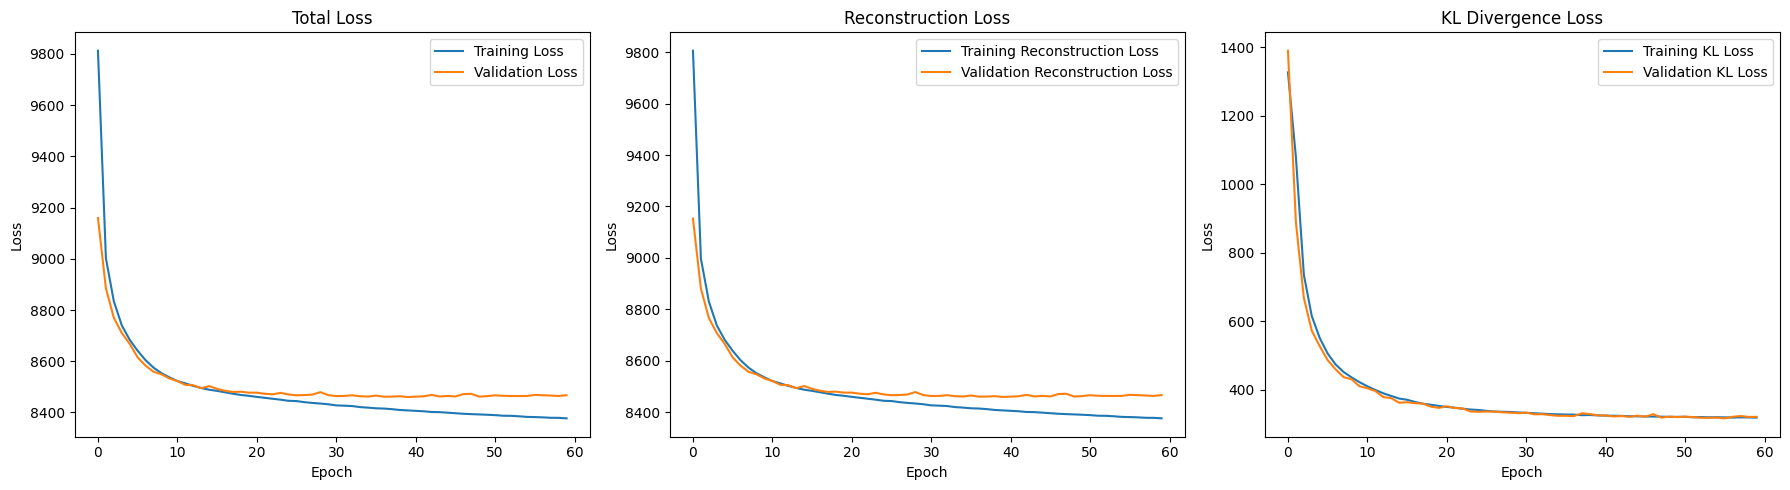


--- Calculating Evaluation Metrics ---


Evaluating Metrics: 100%|██████████| 282/282 [00:53<00:00,  5.28it/s]


--- Final Evaluation Metrics (Validation Set) ---
Average Mean Squared Error (MSE): 0.010936
Average Peak Signal-to-Noise Ratio (PSNR): 19.99 dB
Average Structural Similarity Index (SSIM): 0.5494


In [14]:
print("\n--- Visualizing Training Results ---")
plot_loss_curves(history)
# Calculate and print final evaluation metrics
calculate_and_print_evaluation_metrics(vae, val_dataset)


--- Visualizing Latent Space with PCA ---


Encoding images for PCA: 100%|██████████| 32/32 [00:02<00:00, 13.61it/s]


Running PCA on the latent space...


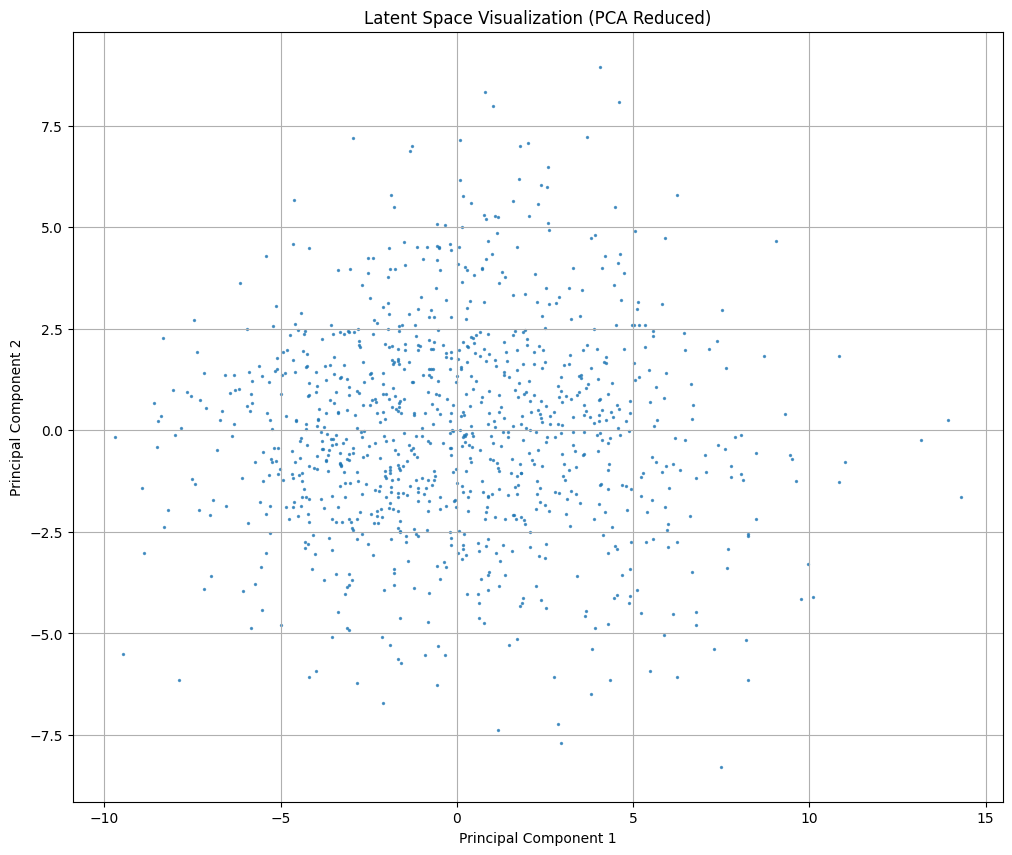

In [15]:
# Visualize the latent space using PCA
plot_latent_space_pca(vae, val_dataset)

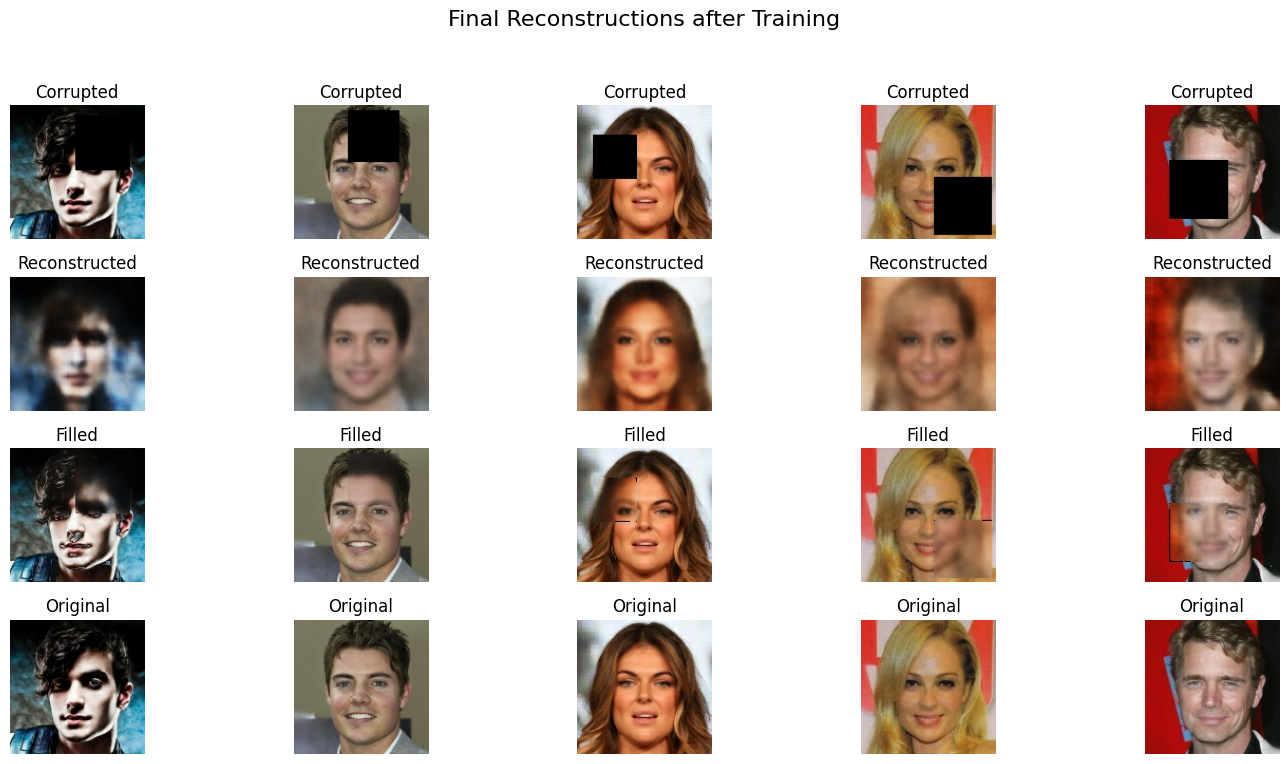

In [16]:
val_data_for_viz = next(iter(val_dataset.batch(5)))
visualize_final_reconstructions(vae, val_data_for_viz)

## Demonstrating the Probabilistic Latent Space
A key feature of a Variational Autoencoder is that it doesn't map an input image to a single, fixed point in the latent space. Instead, it learns a probabilistic distribution—a "cloud" of possible points—that represents the image. This visualization is designed to explore that local cloud for a single, specific image.

The process works as follows:

- Image Selection and Encoding: A single image is chosen from the validation set to act as an anchor. The encoder processes the corrupted version of this image and outputs the parameters (z_mean and z_log_var) of its unique latent distribution. The z_mean can be thought of as the "center" of this cloud.

- Local Neighborhood Sampling: Using the Sampling layer, we repeatedly draw new, random points from this specific distribution. All these points are very close to the original z_mean but have slight, random variations dictated by the learned z_log_var. This is like taking multiple samples from the immediate neighborhood of the image's representation.

- Decoding and Visualization: Each of these sampled points is then passed through the decoder to generate a new image. The final plot displays the original image, its corrupted input, the single "best guess" reconstruction (decoded from z_mean), and a grid of all the other samples.


This grid reveals the subtle, plausible variations the model can generate from a single input, perfectly illustrating the generative power learned within the local neighborhood of an image.

In [17]:
def visualize_local_latent_space(model, image_data, n_grid=5):
    """
    Visualizes the local neighborhood around a single image in the latent space.
    """
    print("\n--- Visualizing Local Latent Space Neighborhood ---")
    # Use the specific image data passed as an argument
    corrupted_image, original_image = image_data
    z_mean, z_log_var = model.encoder.predict(corrupted_image, verbose=0)

    # Generate a grid of samples from the learned distribution
    all_sampled_z = []
    for _ in range(n_grid * n_grid):
        # Sample a new z vector using the reparameterization trick
        sampled_z = Sampling()([z_mean, z_log_var])
        all_sampled_z.append(sampled_z)
    
    all_sampled_z = tf.concat(all_sampled_z, axis=0)

    # Decode all sampled points in a single batch
    print(f"Decoding {len(all_sampled_z)} points from the local neighborhood...")
    reconstructions = model.decoder.predict(all_sampled_z, verbose=0)

    # Create a large canvas to stitch the images together
    canvas = np.zeros((IMAGE_SIZE[0] * n_grid, IMAGE_SIZE[1] * n_grid, 3))
    
    counter = 0
    for i in range(n_grid):
        for j in range(n_grid):
            canvas[
                i * IMAGE_SIZE[0] : (i + 1) * IMAGE_SIZE[0],
                j * IMAGE_SIZE[1] : (j + 1) * IMAGE_SIZE[1],
                :,
            ] = reconstructions[counter]
            counter += 1

    # Also get the single reconstruction from the mean
    reconstructed_from_mean = model.decoder.predict(z_mean, verbose=0)[0]
            
    fig, axs = plt.subplots(1, 4, figsize=(24, 6))
    
    # Original Image
    axs[0].imshow(original_image[0])
    axs[0].set_title("Original Image")
    axs[0].axis("off")

    # Corrupted Image
    axs[1].imshow(corrupted_image[0])
    axs[1].set_title("Corrupted Input")
    axs[1].axis("off")
    
    # Reconstructed from Mean
    axs[2].imshow(reconstructed_from_mean)
    axs[2].set_title("Reconstruction from z_mean")
    axs[2].axis("off")

    # Grid of Samples
    axs[3].imshow(canvas)
    axs[3].set_title(f"{n_grid}x{n_grid} Samples from Local Distribution")
    axs[3].axis("off")
    
    plt.tight_layout()
    plt.show()


--- Visualizing Local Latent Space Neighborhood ---
Decoding 25 points from the local neighborhood...


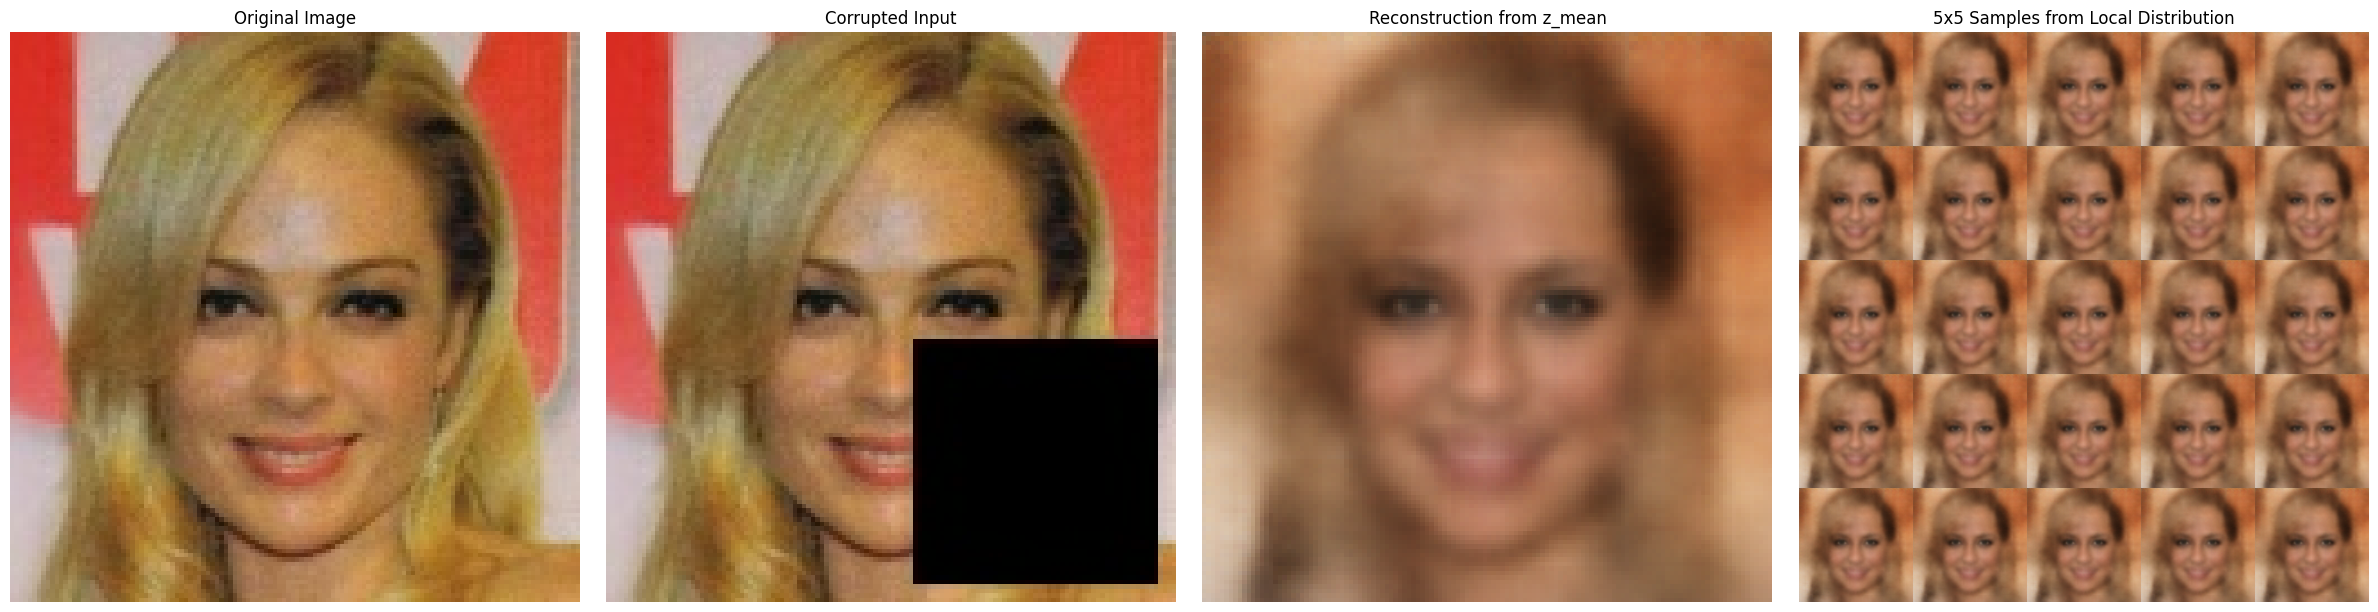

In [18]:
val_data_for_viz = next(iter(val_dataset.batch(5)))
# Demonstrate local latent space sampling on the 4th image from the viz batch
# Index 3 corresponds to the 4th image
image_index = 3
corrupted_img_for_local_viz = val_data_for_viz[0][image_index:image_index+1]
original_img_for_local_viz = val_data_for_viz[1][image_index:image_index+1]
image_data_for_local_viz = (corrupted_img_for_local_viz, original_img_for_local_viz)

visualize_local_latent_space(vae, image_data_for_local_viz)

## Conclusion from the Model's Output
The visualization provides a comprehensive look at the model's capabilities in encoding, reconstructing, and generating complex facial data, even from incomplete information. The results demonstrate a robust and nuanced understanding of facial features.

**Effective Inpainting and Feature Completion**

The most striking insight is the model's ability to perform inpainting. Given the "Corrupted Input" with a significant portion of the face occluded, the model successfully generated a complete and coherent face in the "Reconstruction from z_mean." It correctly inferred the structure of the missing jawline, cheek, and chin based on the context of the visible features. This demonstrates a sophisticated understanding that goes beyond simple one-to-one reconstruction.

**Successful Feature Encoding**

The model has clearly learned the high-level features of the input face. The "Reconstruction from z_mean," while characteristically blurry for a Variational Autoencoder (VAE), accurately captures the essential characteristics:

- The overall face shape and head pose.

- The blonde hair color and style.

- The general placement and appearance of the eyes, nose, and mouth.

This confirms that the encoder is successfully compressing the core identity features into a meaningful latent representation.

**A Stable and Coherent Latent Space**

The grid of "5x5 Samples from Local Distribution" is highly informative. The key observation is that all 25 generated images are recognizably the same person. This indicates that the learned probability distribution for this face in the latent space is stable and compact. The model is confident in its representation, as samples drawn from the neighborhood around the input's encoding consistently decode back to the same identity.

**Learned Generative Variations**

While maintaining the core identity, the 5x5 grid also showcases the model's generative power. Close inspection reveals subtle yet meaningful variations between the samples, such as:

- Minor shifts in lighting and shadow on the cheek and jaw.

- Slight changes in the angle of the chin or the precise shape of the smile.

- Small differences in the texture of the hair.

This demonstrates that the VAE is not producing a single static output but can generate a rich variety of plausible variations, all consistent with its learned understanding of this specific face.